In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [2]:
X=pd.read_csv('Linear_X_Train.csv')
y=pd.read_csv('Linear_Y_Train.csv')

In [3]:
X

,x
0,-0.289307
1,-0.588810
2,1.027507
3,-0.259013
4,0.782043
...,...
3745,-0.100992
3746,1.349197
3747,-0.305164
3748,1.675833


In [4]:
y

,y
0,-0.091101
1,-53.467721
2,75.457009
3,-12.025286
4,57.414187
...,...
3745,-13.530595
3746,114.741657
3747,-34.983275
3748,145.206092


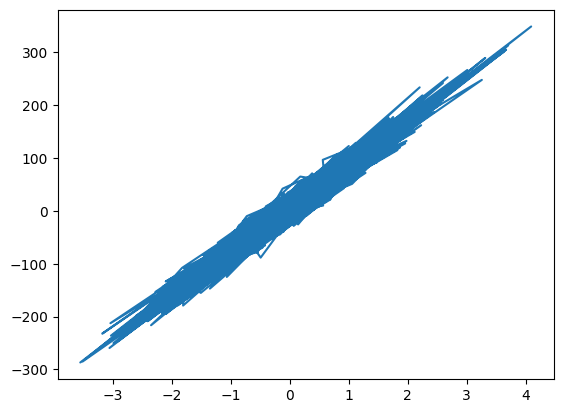

In [5]:
plt.plot(X,y)
plt.show()

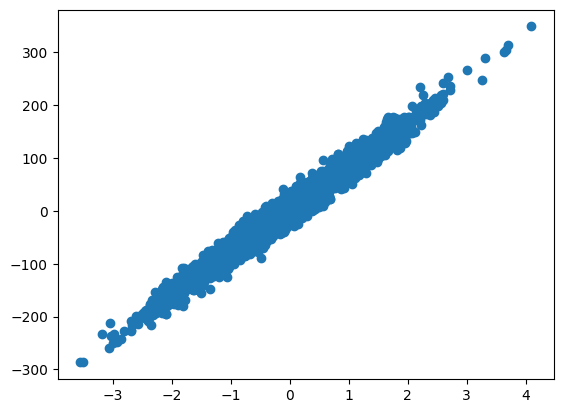

In [6]:
# bht hi khrb sa graph bnke aya 
# ab scatter plot bnaenge
plt.scatter(X,y)
plt.show()


In [13]:
w=np.array([1,2,3,4])
x=np.array([[1,2,3],[10,20,30]])

def hypothesis(x,w):
    ypred=[]
    for row in range(x.shape[0]):
        p=w[0]
        for j in range(x.shape[1]):
            p+=x[row,j]*w[j+1]
        ypred.append(p)
    return ypred
hypothesis(x,w)
    



[21, 201]

In [14]:
a=np.array([1,2,3,4])
b=np.array([10,20,30,40])
a.dot(b)

300

In [15]:
# same dot we are doing here
w=np.array([1,2,3,4])
x=np.array([[1,2,3],[10,20,30]])

def hypothesis(x,w):
    ypred=[]
    for row in range(x.shape[0]):
        p=w[0]
        for j in range(x.shape[1]):
            p+=x[row,j]*w[j+1] # here yaha bi dot krre
            # to ise replace krdenge
        ypred.append(p)
    return ypred
hypothesis(x,w)
    

[21, 201]

In [25]:
w=np.array([2,3,4])
w0=1
x=np.array([[1,2,3],[10,20,30]])


def hypothesis(x,w,w0):
    ypred=[]
    for row in range(x.shape[0]):
        p=x[row].dot(w)+w0
        ypred.append(p)
    return ypred
hypothesis(x,w,w0)
    

[21, 201]

In [26]:
# phle hum w ko x ki row se dot product krke add krre the 
# ab hum x ka transpose krdenge
# or fir dot product
w=np.array([2,3,4])
w0=1
x=np.array([[1,2,3],[10,20,30]])


def hypothesis(x,w,w0):
    return w.dot(x.T)+w0
hypothesis(x,w,w0)
    

array([ 21, 201])

In [27]:
# ab ye same functn upr se jo data h uspe work
# krwaake dkhenge
w=np.array([1]) # upr ek hi row h to w ki value bi ek hogi
# suppose 1 lw li
w0=1

#x=np.array([[1,2,3],[10,20,30]]) ye already given h upr data me


def hypothesis(x,w,w0):
    return w.dot(x.T)+w0
hypothesis(X,w,w0)

array([0.71069258, 0.41119037, 2.02750749, ..., 0.69483634, 2.67583291,
       0.50824276])

In [35]:
# ab loss nikalenge
def loss(x,w,w0,y):
    ypred=hypothesis(x,w,w0)
    return np.mean((ypred-y)**2)
    

In [31]:
loss(x,w,w0,y)

ValueError: shapes (1,) and (3,2) not aligned: 1 (dim 0) != 3 (dim 0)

In [34]:
# ans ni aega kyuki x or y ki dimension same h
X=pd.read_csv('Linear_X_Train.csv').values
y=pd.read_csv('Linear_Y_Train.csv').values.reshape(-1)
# isme hum reshape krdenge y ko

In [37]:
# now run
loss(X,w,w0,y)

6418.398281673329

In [58]:
# ab gradient descent nikaln h
# x or y given hoga lr hoga or epochs 
# hyper param h
def gradientDescent(X,y,lr=0.01,epochs=100):
    w=np.zeros(shape=(X.shape[1],)) 
    # jinte cols honge utne feautures or utni w ki value
    # fir abhi w ki value 0 lelenge
    w0=1
    for e in range(epochs):
        ypred=hypothesis(X,w,w0)
        grads=np.zeros(shape=(X.shape[1],))
        for j in range(w.shape[0]): # jinte w h utne nikalenge 
            # abhi w
            for i in range(X.shape[0]):
                grads[j]+=(ypred[i]-y[i])*X[i,j]
            grads[j]/=X.shape[0]

        w=w-lr*grads
        w0=w0-lr*np.mean(ypred-y)
    return w,w0

            
        
        

In [59]:
w,w0=gradientDescent(X,y)

In [60]:
w

array([50.57180803])

In [61]:
w0

1.5948511659736362

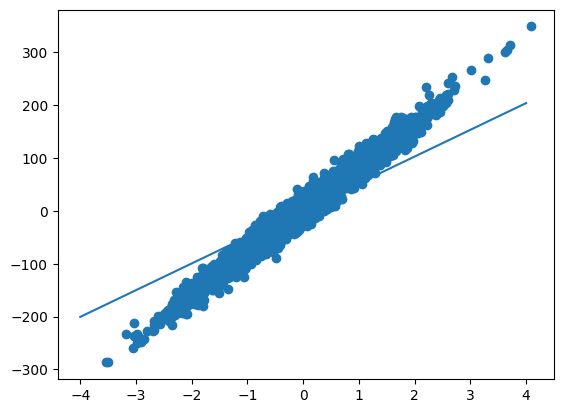

In [62]:
# DOUBT
# ab plot krte h
x=np.linspace(-4,4,1000).reshape((-1,1))
plt.scatter(X,y)
plt.plot(x,hypothesis(x,w,w0))
plt.show()

In [63]:
# AB LOOP HATANA H
def gradientDescent(X,y,lr=0.01,epochs=100):
    w=np.zeros(shape=(X.shape[1],)) 
    # jinte cols honge utne feautures or utni w ki value
    # fir abhi w ki value 0 lelenge
    w0=1
    for e in range(epochs):
        ypred=hypothesis(X,w,w0)
        grads=np.zeros(shape=(X.shape[1],))
        for j in range(w.shape[0]): # jinte w h utne nikalenge 
            # abhi w

            # YAHA SE
            for i in range(X.shape[0]):
                grads[j]+=(ypred[i]-y[i])*X[i,j]
            grads[j]/=X.shape[0]

            # YAHA TK
        w=w-lr*grads
        w0=w0-lr*np.mean(ypred-y)
    return w,w0
